# Mastering Imperfect Information with Deep Recurrent Q-Networks
## Leduc Hold'em — DRQN vs DQN vs Baselines

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/DLPW/blob/master/notebooks/DLPW_colab.ipynb)

**This notebook trains and compares 4 agents:**

1. **DRQN** (Deep Recurrent Q-Network with LSTM memory)
2. **DQN** (Standard feedforward DQN - memoryless baseline)
3. **Random Agent** (baseline)
4. **Heuristic Agent** (rule-based baseline)

**Evaluations:**
- DRQN vs Random, Heuristic, DQN
- DQN vs Random, Heuristic
- **Total: 5 matchups**

**Runtime**: GPU recommended (~2-3 hours)

## 1. Setup & Installation

In [1]:
!pip install -q rlcard torch matplotlib

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Dependencies installed")
print(f"✓ Device: {device}")
print(f"✓ PyTorch version: {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ Dependencies installed
✓ Device: cpu
✓ PyTorch version: 2.10.0+cpu


## 2. Clone Repository

In [2]:
import os
import sys

# Clone repository (change YOUR_USERNAME)
!git clone https://github.com/Aghaei-Amirmasoud/DLPW.git
%cd DLPW

sys.path.insert(0, '/content/DLPW')
print("✓ Repository cloned and path configured")

Cloning into 'DLPW'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 122 (delta 55), reused 105 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 646.47 KiB | 3.99 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/DLPW
✓ Repository cloned and path configured


## 3. Configuration

In [3]:
import config

# Adjust for Colab (increase for better results)
config.NUM_EPISODES_PHASE1 = 8000
config.NUM_EPISODES_PHASE2 = 22000
config.EPSILON_RESET_PHASE2 = None

# Paths
config.OUTPUT_DIR = '/content/DLPW/outputs'
config.MODEL_DIR = '/content/DLPW/outputs/models'
config.PLOT_DIR = '/content/DLPW/outputs/plots'

os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.PLOT_DIR, exist_ok=True)

print("✓ Configuration set")
print(f"  Episodes per phase 1: {config.NUM_EPISODES_PHASE1}")
print(f"  Episodes per phase 2: {config.NUM_EPISODES_PHASE2}")
print(f"  Epsilon reset: {config.EPSILON_RESET_PHASE2}")

✓ Configuration set
  Episodes per phase 1: 8000
  Episodes per phase 2: 22000
  Epsilon reset: None


## 4. Import Modules

In [4]:
import rlcard
from rlcard.utils import set_seed
from rlcard.agents import RandomAgent, DQNAgent
import matplotlib.pyplot as plt
import numpy as np
import logging

from config import *
from agents import DRQNAgent, ConservativeHeuristicAgent
from training import CurriculumTrainer
from evaluation import (
    evaluate_agents,
    compute_action_distribution,
    print_evaluation_summary,
    print_advanced_analysis,
    compare_agents,
    statistical_significance,
    analyze_queen_play,
    analyze_round_performance,
    compare_queen_play
)
from analysis import plot_training_curves, plot_comparison_curves, plot_ev_comparison_bar

# Suppress RLCard INFO logs
logging.getLogger('rlcard').setLevel(logging.WARNING)

print("✓ All modules imported")

✓ All modules imported


## 5. Environment Setup

In [5]:
set_seed(SEED)
env = rlcard.make(ENV_NAME)

raw_shape = env.state_shape[0]
state_shape = raw_shape[0] if isinstance(raw_shape, list) else raw_shape
num_actions = env.num_actions

print(f'✓ Environment: {ENV_NAME}')
print(f'✓ State shape: {state_shape}, Actions: {num_actions}')

✓ Environment: leduc-holdem
✓ State shape: 36, Actions: 4


## 6. Initialize Agents

In [6]:
# DRQN Agent (with LSTM memory)
agent_drqn = DRQNAgent(
    state_shape=state_shape,
    num_actions=num_actions,
    device=DEVICE,
    hidden_size=HIDDEN_SIZE,
    lr=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=BUFFER_CAPACITY,
    batch_size=BATCH_SIZE,
    min_replay=MIN_REPLAY_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
)

# DQN Agent (feedforward baseline)
agent_dqn = DQNAgent(
    num_actions=num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[HIDDEN_SIZE, HIDDEN_SIZE],
    device=DEVICE
)

# Baseline agents
agent_random = RandomAgent(num_actions)
agent_heuristic = ConservativeHeuristicAgent(num_actions)

print("✓ All agents initialized")

✓ All agents initialized


## 7. Train DRQN (Two-Phase Curriculum)

**Phase 1**: Learn basic card strength against Random agent  
**Phase 2**: Learn exploitation against Heuristic agent

**Epsilon Reset Experiment**: Set `config.EPSILON_RESET_PHASE2` to test if resetting exploration helps:
- `None` (default): No reset, epsilon continues decaying from Phase 1 (~0.05)
- `0.3`: Moderate reset, balances exploration vs preserving Phase 1 knowledge
- `0.5`: High reset, more aggressive exploration
- `1.0`: Full reset, maximum exploration (risk of catastrophic forgetting)

**Rationale**: DRQN's low Queen win rate (42.9% vs DQN's 58.8%) may be due to insufficient exploration during Phase 2. Resetting epsilon allows the agent to discover more aggressive Round 2 strategies vs Heuristic.

In [7]:
trainer_drqn = CurriculumTrainer(
    env=env,
    agent=agent_drqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

drqn_history = trainer_drqn.train()

# Save model
agent_drqn.save_model(DRQN_CHECKPOINT)
print(f"\n✓ DRQN training complete. Model saved to {DRQN_CHECKPOINT}")

PHASE 1: Training vs Random Agent (0-8000)
[P1] Ep 00000 | ε=1.000 | EV vs Random: +1.166 | EV vs Heuristic: -1.049
[P1] Ep 01000 | ε=0.708 | EV vs Random: +0.938 | EV vs Heuristic: -0.861
[P1] Ep 02000 | ε=0.429 | EV vs Random: +0.938 | EV vs Heuristic: -0.696
[P1] Ep 03000 | ε=0.260 | EV vs Random: +0.994 | EV vs Heuristic: -0.698
[P1] Ep 04000 | ε=0.158 | EV vs Random: +1.075 | EV vs Heuristic: -0.435
[P1] Ep 05000 | ε=0.096 | EV vs Random: +0.939 | EV vs Heuristic: -0.777
[P1] Ep 06000 | ε=0.058 | EV vs Random: +1.149 | EV vs Heuristic: -0.471
[P1] Ep 07000 | ε=0.035 | EV vs Random: +1.181 | EV vs Heuristic: -0.421

PHASE 2: Fine-tuning vs Heuristic (8000-30000)
[P2] Ep 08000 | ε=0.021 | EV vs Random: +0.902 | EV vs Heuristic: -0.416
[P2] Ep 09000 | ε=0.013 | EV vs Random: +0.854 | EV vs Heuristic: +0.041
[P2] Ep 10000 | ε=0.008 | EV vs Random: +1.016 | EV vs Heuristic: +0.182
[P2] Ep 11000 | ε=0.005 | EV vs Random: +0.705 | EV vs Heuristic: +0.403
[P2] Ep 12000 | ε=0.003 | EV vs R

## 8. Train DQN (Baseline Comparison)

In [8]:
trainer_dqn = CurriculumTrainer(
    env=env,
    agent=agent_dqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

dqn_history = trainer_dqn.train()
print("\n✓ DQN training complete")

PHASE 1: Training vs Random Agent (0-8000)
[P1] Ep 00000 | ε=0.000 | EV vs Random: +0.470 | EV vs Heuristic: -0.884
INFO - Step 35, rl-loss: 2.449300527572632
INFO - Copied model parameters to target network.
INFO - Step 626, rl-loss: 1.1601171493530273
INFO - Copied model parameters to target network.
INFO - Step 1203, rl-loss: 0.8824788331985474
INFO - Copied model parameters to target network.
INFO - Step 1298, rl-loss: 4.507588863372803[P1] Ep 01000 | ε=0.000 | EV vs Random: +0.980 | EV vs Heuristic: -0.247
INFO - Step 1780, rl-loss: 1.0622875690460205
INFO - Copied model parameters to target network.
INFO - Step 2352, rl-loss: 1.913145661354065
INFO - Copied model parameters to target network.
INFO - Step 2646, rl-loss: 0.9173915386199951[P1] Ep 02000 | ε=0.000 | EV vs Random: +1.185 | EV vs Heuristic: -0.885
INFO - Step 2921, rl-loss: 0.48673564195632935
INFO - Copied model parameters to target network.
INFO - Step 3492, rl-loss: 1.2942960262298584
INFO - Copied model parameters 

## 9. Training Curves Visualization

Saved training curves to /content/DLPW/outputs/plots/drqn_training_curves.png


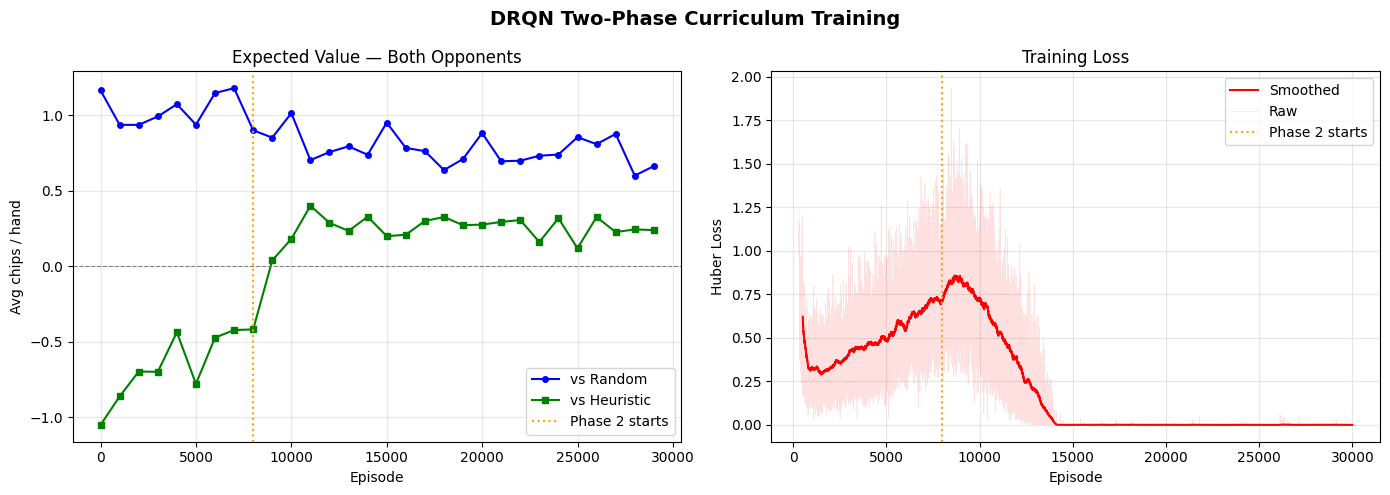

In [9]:
# DRQN training curves
plot_training_curves(
    ev_history_random=drqn_history['ev_random'],
    ev_history_heuristic=drqn_history['ev_heuristic'],
    loss_history=drqn_history['loss'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_training_curves.png'
)

Saved comparison curves to /content/DLPW/outputs/plots/drqn_vs_dqn_comparison.png


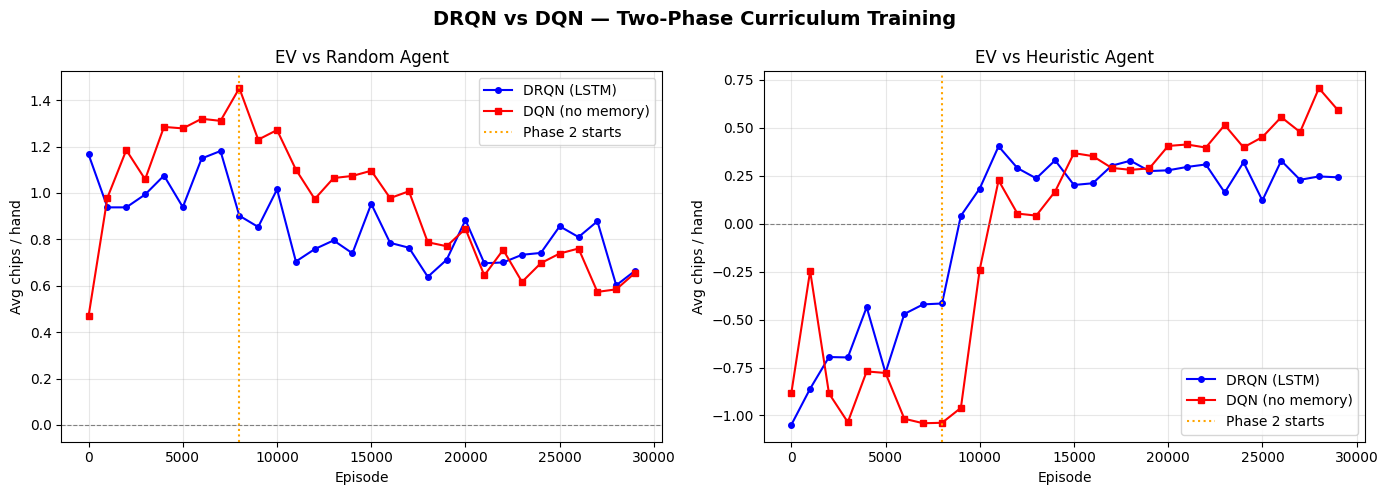

In [10]:
# DRQN vs DQN comparison
plot_comparison_curves(
    drqn_hist_random=drqn_history['ev_random'],
    drqn_hist_heuristic=drqn_history['ev_heuristic'],
    dqn_hist_random=dqn_history['ev_random'],
    dqn_hist_heuristic=dqn_history['ev_heuristic'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_vs_dqn_comparison.png'
)

## 10. Final Evaluation

In [11]:
print(f"\n{'='*60}")
print(f"FINAL EVALUATION ({NUM_EVAL_HANDS} hands per matchup)")
print(f"{'='*60}")

results = {}

# DRQN evaluations
print('\nDRQN vs ...')
ev_vs_random, traj_drqn_vs_random = evaluate_agents(
    env, agent_drqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
ev_vs_heuristic, traj_drqn_vs_heuristic = evaluate_agents(
    env, agent_drqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)
ev_vs_dqn, traj_drqn_vs_dqn = evaluate_agents(
    env, agent_drqn, agent_dqn, NUM_EVAL_HANDS, 'Standard DQN'
)

# DQN evaluations
print('\nDQN vs ...')
dqn_vs_random, traj_dqn_vs_random = evaluate_agents(
    env, agent_dqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
dqn_vs_heuristic, traj_dqn_vs_heuristic = evaluate_agents(
    env, agent_dqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)

# Store results
results['DRQN vs Random'] = {
    'ev': ev_vs_random,
    'trajectories': traj_drqn_vs_random,
    'action_stats': compute_action_distribution(traj_drqn_vs_random, ACTION_NAMES)
}
results['DRQN vs Heuristic'] = {
    'ev': ev_vs_heuristic,
    'trajectories': traj_drqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_drqn_vs_heuristic, ACTION_NAMES)
}
results['DRQN vs DQN'] = {
    'ev': ev_vs_dqn,
    'trajectories': traj_drqn_vs_dqn,
    'action_stats': compute_action_distribution(traj_drqn_vs_dqn, ACTION_NAMES)
}
results['DQN vs Random'] = {
    'ev': dqn_vs_random,
    'trajectories': traj_dqn_vs_random,
    'action_stats': compute_action_distribution(traj_dqn_vs_random, ACTION_NAMES)
}
results['DQN vs Heuristic'] = {
    'ev': dqn_vs_heuristic,
    'trajectories': traj_dqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_dqn_vs_heuristic, ACTION_NAMES)
}


FINAL EVALUATION (5000 hands per matchup)

DRQN vs ...
  Random                        : +0.757 chips/hand
  Heuristic                     : +0.315 chips/hand
  Standard DQN                  : +0.281 chips/hand

DQN vs ...
  Random                        : +0.850 chips/hand
  Heuristic                     : +0.536 chips/hand


## 11. Evaluation Summary & Analysis

In [12]:
# Detailed summary with action distributions and bluff rates
print_evaluation_summary(results)


FINAL EVALUATION SUMMARY

DRQN vs Random
----------------------------------------
  Expected Value: +0.757 chips/hand
  Action Distribution:
    Raise   :  5465 (44.1%)
    Call    :  3544 (28.6%)
    Fold    :  2711 (21.9%)
    Check   :   664 (5.4%)
  Bluff Rate (raise with Jack): 48.1%  (1918/3985 decisions)

DRQN vs Heuristic
----------------------------------------
  Expected Value: +0.315 chips/hand
  Action Distribution:
    Raise   :  7655 (56.7%)
    Fold    :  5335 (39.5%)
    Check   :   501 (3.7%)
    Call    :     0 (0.0%)
  Bluff Rate (raise with Jack): 53.0%  (2455/4635 decisions)

DRQN vs DQN
----------------------------------------
  Expected Value: +0.281 chips/hand
  Action Distribution:
    Fold    :  7627 (45.8%)
    Raise   :  5018 (30.1%)
    Call    :  3454 (20.7%)
    Check   :   554 (3.3%)
  Bluff Rate (raise with Jack): 26.3%  (1455/5533 decisions)

DQN vs Random
----------------------------------------
  Expected Value: +0.850 chips/hand
  Action Distributi

## 12. Advanced Analysis

Detailed poker metrics including VPIP, aggression factor, and win rate by hand strength.

In [13]:
# Advanced analysis for all matchups
print_advanced_analysis(results)


ADVANCED ANALYSIS

DRQN vs Random
----------------------------------------
  Playing Style Metrics:
    VPIP (Voluntary Put in Pot):  65.2%
    PFR (Pre-Flop Raise):          37.6%
    Aggression Factor:             1.54
    Went to Showdown:              69.0%
    Fold Percentage:               14.2%
  Round-Specific Aggression:
    Round 1 (Pre-Flop):            43.7% raises
    Round 2 (Post-Flop):           44.5% raises
  Performance by Starting Hand:
    K: 1444/1712 wins (84.3%) | Avg Payoff: +1.24
    Q: 1280/1692 wins (75.7%) | Avg Payoff: +0.74
    J: 1102/1596 wins (69.0%) | Avg Payoff: +0.26

DRQN vs Heuristic
----------------------------------------
  Playing Style Metrics:
    VPIP (Voluntary Put in Pot):  50.3%
    PFR (Pre-Flop Raise):          50.3%
    Aggression Factor:             7655.00
    Went to Showdown:              53.7%
    Fold Percentage:               29.5%
  Round-Specific Aggression:
    Round 1 (Pre-Flop):            58.4% raises
    Round 2 (Post-Flo

## 13. Head-to-Head Comparison: DRQN vs DQN

Direct comparison with playing style metrics.

In [14]:
# Detailed DRQN vs DQN comparison
compare_agents(results, 'DRQN', 'DQN')


HEAD-TO-HEAD COMPARISON: DRQN vs DQN

Direct Matchup:
  DRQN EV: +0.281 chips/hand
  Result: DRQN WINS decisively

Performance vs Baselines:

  vs Random:
    DRQN: +0.757
    DQN: +0.850
    Difference: -0.093 (DQN better)

  vs Heuristic:
    DRQN: +0.315
    DQN: +0.536
    Difference: -0.222 (DQN better)

Playing Style Comparison:

  Metric                               DRQN              DQN
  -------------------------------------------------------
  VPIP                                65.2%            61.2%
  Pre-Flop Raise                      37.6%            43.1%
  Aggression Factor                   1.54             1.95
  Went to Showdown                    69.0%            66.8%
  Round 1 Aggression                  43.7%            55.2%
  Round 2 Aggression                  44.5%            33.7%


## 14. Statistical Significance Analysis

Verify the DRQN advantage is statistically robust.

In [15]:
# Statistical significance test
sig_test = statistical_significance(results['DRQN vs DQN']['ev'], NUM_EVAL_HANDS)

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST: DRQN vs DQN")
print("="*60)
print(f"\nExpected Value: {sig_test['ev']:+.3f} chips/hand")
print(f"Standard Error: ±{sig_test['std_error']:.3f}")
print(f"95% Confidence Interval: [{sig_test['ci_95_lower']:+.3f}, {sig_test['ci_95_upper']:+.3f}]")
print(f"Z-score: {sig_test['z_score']:.2f}")
print(f"P-value: {sig_test['p_value']:.6f}")
print(f"\nStatistically Significant (α=0.05): {'YES ✓' if sig_test['significant'] else 'NO'}")

if sig_test['significant']:
    print("\n" + "="*60)
    print("CONCLUSION: DRQN's memory advantage is STATISTICALLY ROBUST")
    print("="*60)
    print("The LSTM memory provides a significant competitive advantage")
    print("that cannot be attributed to random chance.")


STATISTICAL SIGNIFICANCE TEST: DRQN vs DQN

Expected Value: +0.281 chips/hand
Standard Error: ±0.028
95% Confidence Interval: [+0.225, +0.336]
Z-score: 9.92
P-value: 0.000000

Statistically Significant (α=0.05): YES ✓

CONCLUSION: DRQN's memory advantage is STATISTICALLY ROBUST
The LSTM memory provides a significant competitive advantage
that cannot be attributed to random chance.


## 15. Queen Play Investigation

Detailed analysis of the Queen misplay problem.

In [16]:
# Compare how DRQN and DQN play Queens
compare_queen_play(results, 'DRQN', 'DQN')


QUEEN PLAY COMPARISON: DRQN vs DQN

DRQN Queens vs Heuristic:
  Total Queen Hands: 1729
  Win Rate: 66.1%
  Average Payoff: +0.396
  Fold Rate: 33.9%
  Showdown Rate: 66.1%

  Round 1 Actions:
    Raise:  50.2%
    Call:   0.0%
    Check:  0.0%
    Fold:   49.8%

  Round 2 Actions:
    Raise:  55.4%
    Call:   0.0%
    Check:  0.0%
    Fold:   44.6%

DQN Queens vs Heuristic:
  Total Queen Hands: 1643
  Win Rate: 68.4%
  Average Payoff: +0.472
  Fold Rate: 31.6%
  Showdown Rate: 68.4%

  Round 1 Actions:
    Raise:  61.7%
    Call:   0.0%
    Check:  0.0%
    Fold:   38.3%

  Round 2 Actions:
    Raise:  47.9%
    Call:   0.0%
    Check:  0.0%
    Fold:   52.1%

KEY DIFFERENCES:

Win Rate Gap: -2.3 percentage points (DRQN)
Round 1 Raise Rate: -11.5% (DRQN)
Round 2 Raise Rate: +7.5% (DRQN)


## 16. Round Performance Analysis

Where do mistakes happen - Round 1 or Round 2?

In [17]:
# Analyze round-specific performance
print("\n" + "="*60)
print("ROUND-BY-ROUND ANALYSIS")
print("="*60)

for agent_name in ['DRQN', 'DQN']:
    key = f'{agent_name} vs Heuristic'
    if key in results and 'trajectories' in results[key]:
        stats = analyze_round_performance(results[key]['trajectories'])

        print(f'\n{agent_name} vs Heuristic:')
        print(f"  Round 1 Folds: {stats.get('fold_round1_pct', 0):.1f}%")
        print(f"  Round 2 Folds: {stats.get('fold_round2_pct', 0):.1f}%")
        print(f"  Showdown Rate: {stats.get('showdown_pct', 0):.1f}%")

        if 'round1_aggressive_win_rate' in stats:
            print(f"  Round 1 Raise Success: {stats['round1_aggressive_win_rate']:.1f}%")
        if 'round2_aggressive_win_rate' in stats:
            print(f"  Round 2 Raise Success: {stats['round2_aggressive_win_rate']:.1f}%")


ROUND-BY-ROUND ANALYSIS

DRQN vs Heuristic:
  Round 1 Folds: 29.5%
  Round 2 Folds: 0.0%
  Showdown Rate: 70.5%
  Round 1 Raise Success: 87.5%
  Round 2 Raise Success: 86.5%

DQN vs Heuristic:
  Round 1 Folds: 27.1%
  Round 2 Folds: 0.0%
  Showdown Rate: 72.9%
  Round 1 Raise Success: 86.7%
  Round 2 Raise Success: 79.8%
